# 3.3 Partitionnement (*clustering*) : la classification non supervisée

🖥️ [**Diapositives du cours — Séance 13 (mer. 28 oct.)**](https://geo-smart.github.io/mlgeo-book/slides/2026/lec13_clustering.html)

Le partitionnement (*clustering*) est une forme de *classification non supervisée* : l'algorithme découvre la structure des données à partir des seules caractéristiques (*features*), sans étiquettes. Le but est de grouper les observations en sous-groupes cohérents.

Qu'un groupe soit cohérent ou non dépend de la *distance* entre les points de données. La métrique de distance quantifie la similarité ou la dissimilarité de deux points de données, et tout algorithme de partitionnement repose sur l'une d'elles.

Ce tutoriel ne couvre pas toutes les méthodes de partitionnement possibles. Aucune méthode ne domine dans tous les scénarios ; le bon choix dépend fortement de la structure intrinsèque des données. Un résumé simple, avec des exemples jouets de structures de données 2D, est disponible dans le [paquet sklearn](https://scikit-learn.org/stable/modules/clustering.html#overview-of-clustering-methods).

Cette leçon se concentre sur des concepts fondamentaux pertinents pour les géosciences : 1) la définition de la ***distance***, illustrée par l'algorithme de partitionnement le plus populaire, 2) le partitionnement k-means, et 3) le partitionnement agglomératif.

## 1. Distance
La distance est la mesure élémentaire de dissimilarité entre points de données, et les résultats du partitionnement dépendent directement de la métrique choisie. La distance revient plus tard dans le cours comme brique de base des fonctions de perte et de coût pour l'entraînement des modèles d'apprentissage profond.

Il existe divers moyens d'estimer et de quantifier la distance entre points de données. Parmi les métriques de distance les plus utilisées :

* **Distance euclidienne** : la distance en ligne droite entre deux points de données dans un espace multidimensionnel. Elle sert souvent quand les caractéristiques ont des unités ou des échelles comparables.
        $d(\mathbf{x},\mathbf{y}) = \sqrt{ \sum_{i=1}^N (x_i-y_i)^2  }$

* **Distance de Manhattan** : dite aussi distance « L1 », elle mesure la somme des différences absolues entre les éléments correspondants de deux points de données. Elle convient quand le déplacement le long des axes est contraint, comme dans des données en grille.
        $d(\mathbf{x},\mathbf{y}) =  \sum_{i=1}^N |x_i-y_i| $

* **Distance géodésique** : la distance géodésique mesure le plus court chemin entre deux points à la surface d'une sphère. Elle compte pour la géographie terrestre, y compris la navigation GPS et les mesures géodésiques.

* **Distances fondées sur la corrélation** : en analyse de données géophysiques et géospatiales, les métriques de distance fondées sur la corrélation, comme la *corrélation de Pearson* ou la *corrélation de rang de Spearman*, servent souvent à évaluer les relations entre variables.

* **Distances fondées sur la covariance** : ces distances, qui prennent en compte la covariance spatiale ou les modèles de variogramme, sont répandues en géostatistique et en analyse spatiale.

* **Similarité cosinus** : cette métrique calcule le cosinus de l'angle entre deux vecteurs de données, mesure de leur similarité, en particulier dans les espaces de grande dimension. Elle est fréquente pour les données de texte ou d'image.

Scikit-learn regroupe les métriques les plus courantes du ML classique dans le module ``metrics.DistanceMetric``. Plus de détails dans cette [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.DistanceMetric.html) scikit-learn.

***Lien avec la PCA***
Le partitionnement et la PCA (analyse en composantes principales) simplifient tous deux les données par un petit nombre de résumés. Mais les différences sont :
* la PCA cherche à réduire la dimension des données, à trouver une représentation de faible dimension qui explique une bonne fraction de la variance des données,
* le partitionnement cherche des groupes homogènes au sein des observations.

De fait, il est courant de combiner les deux pour des données complexes et de grande dimension : 1) PCA, 2) partitionnement sur les composantes principales.

Il existe deux grandes méthodes de partitionnement : le partitionnement **k-means** et le **partitionnement hiérarchique**.

La boîte à outils scikit-learn offre une collection d'algorithmes de partitionnement et une [documentation](https://scikit-learn.org/stable/modules/clustering.html) détaillée avec tutoriels.

## 2. Mise en place du tutoriel
Importons les paquets Python utiles.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pooch
from sklearn import preprocessing
from sklearn.decomposition import PCA

# one generator for the whole notebook, the idiom from 2.6
rng = np.random.default_rng(42)

### Données

Les éditions précédentes de ce chapitre utilisaient une table de cytométrie en flux SeaFlow de 146 Mo ; nous l'avons retirée en 2026 au profit de jeux de données plus légers.

Notre premier jeu de travail est l'enregistrement du geyser Old Faithful, à Yellowstone. Chaque ligne apparie la durée d'une éruption (`current`, en minutes) avec la durée de l'éruption suivante (`next`, en minutes). Nous le téléchargeons avec `pooch`, qui met le fichier en cache localement.

In [2]:
path = pooch.retrieve(
    url="https://raw.githubusercontent.com/UW-MLGEO/MLGeo-dataset/main/data/faithful.csv",
    known_hash=None,
    fname="faithful.csv",
    path=pooch.os_cache("mlgeo"),
)
faithful = pd.read_csv(path)
faithful.head()

,current,next
0,3.600,1.800
1,1.800,3.333
2,3.333,2.283
3,2.283,4.533
4,4.533,2.883


Text(0.5, 1.0, 'Old Faithful')

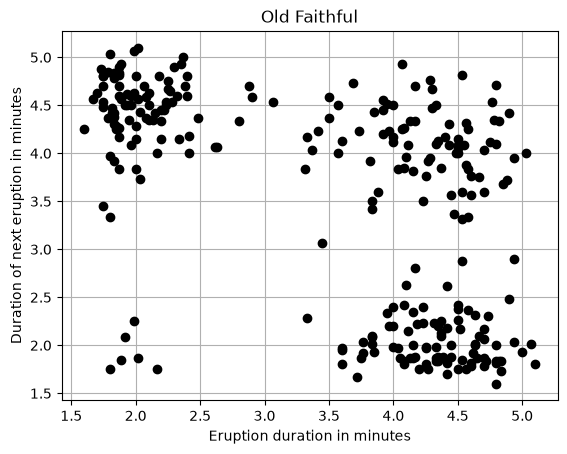

In [3]:
plt.plot(faithful.current, faithful.next, 'ko')
plt.xlabel('Eruption duration in minutes')
plt.ylabel('Duration of next eruption in minutes')
plt.grid(True)
plt.title('Old Faithful')

K-means repose sur la distance euclidienne, donc les caractéristiques aux plages numériques les plus larges dominent le résultat. Ici, les deux colonnes se trouvent être en minutes, avec des plages similaires, mais c'est une coïncidence propre à ce jeu de données. Standardiser chaque caractéristique (moyenne nulle, variance unité) est une habitude à garder pour toute méthode fondée sur la distance — dans l'exercice sismique en fin de carnet, les caractéristiques couvrent plusieurs ordres de grandeur et la mise à l'échelle n'est pas optionnelle. Nous standardisons maintenant et stockons le résultat dans `data_faithful`, un tableau numpy à 2 colonnes.

In [4]:
scaler = preprocessing.StandardScaler()
data_faithful = scaler.fit_transform(faithful[["current", "next"]])
print(data_faithful.shape)

(271, 2)


## 3. K-means
K-means est une méthode de partitionnement non supervisée. L'idée principale est de séparer les données en K groupes (*clusters*) distincts. Deux problèmes se posent alors. D'abord, trouver les k centroïdes des k groupes. Ensuite, affecter chaque point de données au groupe dont le centroïde est le plus proche du point.

Le but est de partitionner $n$ points de données en $k$ groupes. Chaque observation est rattachée au groupe de moyenne la plus proche.

K-means est itératif :
1. supposer des valeurs initiales pour la moyenne de chacun des $k$ groupes
2. calculer la distance de chaque observation à chacune des $k$ moyennes
3. étiqueter chaque observation comme appartenant à la moyenne la plus proche
4. trouver le *centre de masse* (la moyenne) de chaque groupe de points étiquetés. Ce sont les nouvelles moyennes pour l'étape 1.

Dans la suite, nous notons $n$ le nombre de points de données et $p$ le nombre de caractéristiques de chaque point.

K-means ne fonctionne qu'avec la métrique de **distance euclidienne**. Son concept central est justement d'utiliser la distance euclidienne pour mesurer et minimiser l'*inertie*, ou *variance intra-groupe*.

In [5]:
n, p = data_faithful.shape
print('We have {:d} data points, and each one has {:d} features'.format(n, p))

We have 271 data points, and each one has 2 features


Définissons une fonction pour initialiser les centroïdes des groupes. Nous choisissons des points aléatoires dans la plage des valeurs prises par les données.

In [6]:
def init_centers(data, k):
    """
    """
    # Initialize centroids
    centers = np.zeros((k, np.shape(data)[1]))
    # Loop on k centers
    for i in range(0, k):
        # Generate p random values between 0 and 1
        dist = rng.uniform(size=np.shape(data)[1])
        # Use the random values to generate a point within the range of values taken by the data
        centers[i, :] = np.min(data, axis=0) + (np.max(data, axis=0) - np.min(data, axis=0)) * dist
    return centers

Pour pouvoir affecter chaque point de données au centroïde le plus proche, il faut définir la distance entre deux points de données. La plus courante est la **distance euclidienne** :

$d(x,y) = \sqrt{\sum_{i = 1}^p (x_i - y_i)^2}$

où $x$ et $y$ sont deux points d'observation à $p$ variables.

Nous définissons ensuite une fonction qui calcule la distance entre chaque point de données et chaque centroïde.

In [7]:
def compute_distance(data, centers, k):
    """
    """
    # Initialize distance
    distance = np.zeros((np.shape(data)[0], k))
    # Loop on n data points
    for i in range(0, np.shape(data)[0]):
        # Loop on k centroids
        for j in range(0, k):
            # Compute distance
            distance[i, j] = np.sqrt(np.sum(np.square(data[i, :] - centers[j, :])))
    return distance

Définissons maintenant une fonction qui affecte chaque point de données au groupe dont le centroïde est le plus proche du point. Nous définissons aussi une fonction objectif, qui sera minimisée jusqu'à convergence.

Notre objectif est de minimiser la somme des carrés des distances entre chaque point et le centroïde le plus proche :

$obj = \sum_{j = 1}^k \sum_{i = 1}^{N_j} d(x^{(i)} , x^{(j)}) ^2$

où $x^{(i)}$ est le point $i$ du groupe $j$, $x^{(j)}$ le centroïde du groupe $j$, et $N_j$ le nombre de points du groupe $j$.

In [8]:
def compute_objective(distance, clusters):
    """
    """
    # Initialize objective
    objective = 0.0
    # Loop on n data points
    for i in range(0, np.shape(distance)[0]):
        # Add distance to the closest centroid
        objective = objective + distance[i, int(clusters[i])] ** 2.0
    return objective

In [9]:
def compute_clusters(distance):
    """
    """
    # Initialize clusters
    clusters = np.zeros(np.shape(distance)[0])
    # Loop on n data points
    for i in range(0, np.shape(distance)[0]):
        # Find closest centroid
        best = np.argmin(distance[i, :])
        # Assign data point to corresponding cluster
        clusters[i] = best
    return clusters

Une fois tous les points assignés à un groupe, calculons la nouvelle position du centroïde. C'est simplement la moyenne de tous les points affectés à ce groupe :

Pour $1 \leq j \leq k$, $x_p^{(j)} = \frac{1}{N_j} \sum_{i = 1}^{N_j} x_p^{(i)}$

In [10]:
def compute_centers(data, clusters, k):
    """
    """
    # Initialize centroids
    centers = np.zeros((k, np.shape(data)[1]))
    # Loop on clusters
    for i in range(0, k):
        # Select all data points in this cluster
        subdata = data[clusters == i, :]
        # If no data point in this cluster, generate randomly a new centroid
        if (np.shape(subdata)[0] == 0):
            centers[i, :] = init_centers(data, 1)
        else:
            # Compute the mean location of all data points in this cluster
            centers[i, :] = np.mean(subdata, axis=0)
    return centers

Nous pouvons maintenant coder l'algorithme K-means en assemblant toutes ces fonctions. Nous arrêtons le calcul quand la fonction objectif ne décroît plus.

In [11]:
def my_kmeans(data, k):
    """
    """
    # Initialize centroids
    centers = init_centers(data, k)
    # Initialize objective function to square of the maximum distance between two data points times number of data points
    objective_old = np.shape(data)[0] * np.sum(np.square(np.max(data, axis=0) - np.min(data, axis=0)))
    # Initialize clusters
    clusters_old = np.zeros(np.shape(data)[0])
    # Start loop until convergence
    stop_alg = False
    while stop_alg == False:
        # Compute distance between data points and centroids
        distance = compute_distance(data, centers, k)
        # Get new clusters
        clusters_new = compute_clusters(distance)
        # get new value of objective function
        objective_new = compute_objective(distance, clusters_new)
        # If objective function stops decreasing, end loop
        if objective_new >= objective_old:
            return (clusters_old, objective_old, centers)
        else:
            # Update the locations of the centroids
            centers = compute_centers(data, clusters_new, k)
            objective_old = objective_new
            clusters_old = clusters_new

Les données d'Old Faithful montrent deux régimes — des éruptions courtes suivies d'éruptions courtes, et des éruptions longues suivies d'éruptions longues — donc nous posons `k = 2` et lançons notre k-means écrit à la main.

Text(0.5, 1.0, 'From-scratch k-means with k = 2')

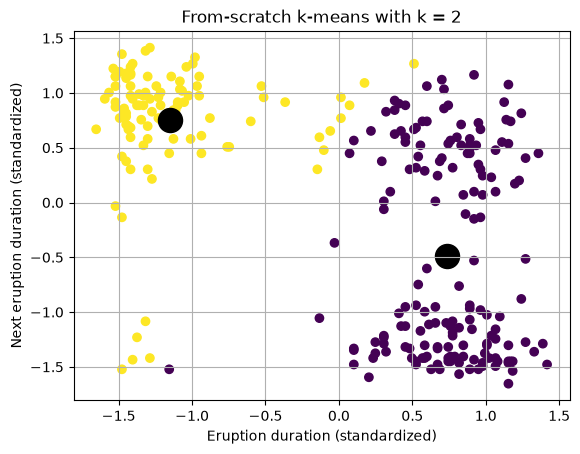

In [12]:
k = 2
(clusters, objective, centers) = my_kmeans(data_faithful, k)

plt.scatter(data_faithful[:, 0], data_faithful[:, 1], c=clusters)
plt.scatter(centers[:, 0], centers[:, 1], marker='o', s=300, c='black')
plt.xlabel('Eruption duration (standardized)')
plt.ylabel('Next eruption duration (standardized)')
plt.grid(True)
plt.title('From-scratch k-means with k = 2')

### K-means avec scikit-learn

Nous utilisons maintenant l'implémentation de [scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) sur les mêmes données mises à l'échelle.

Deux valeurs par défaut à connaître : `init='k-means++'` est le schéma d'initialisation par défaut, et depuis les versions récentes de scikit-learn, `n_init` vaut par défaut `'auto'`, qui lance plusieurs redémarrages k-means++ et garde le meilleur. Vous n'avez plus besoin de régler l'un ou l'autre de ces paramètres à la main.

Text(0.5, 1.0, 'Scikit-learn KMeans with k = 2')

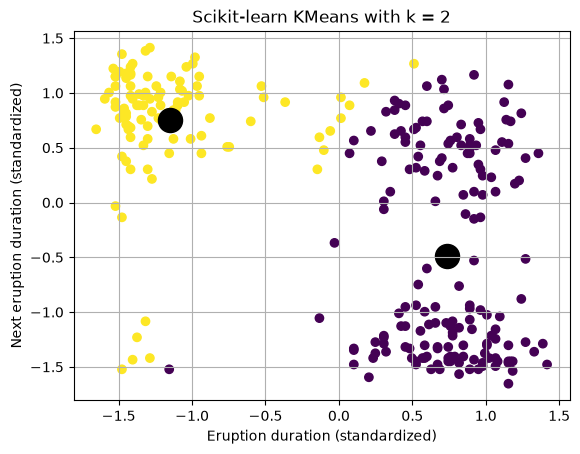

In [13]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=0).fit(data_faithful)

plt.scatter(data_faithful[:, 0], data_faithful[:, 1], c=kmeans.labels_)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='o', s=300, c='black')
plt.xlabel('Eruption duration (standardized)')
plt.ylabel('Next eruption duration (standardized)')
plt.grid(True)
plt.title('Scikit-learn KMeans with k = 2')

### Conseils pratiques pour k-means

1. Comment **évaluer la réussite** du partitionnement ? Les groupes sont-ils bien séparés ? Il existe de nombreuses façons d'évaluer la qualité des groupes. Scikit-learn a résumé et empaqueté ces outils dans le module ``sklearn.metrics``. Voir la documentation [ici](https://scikit-learn.org/stable/modules/clustering.html#clustering-evaluation). En général, un score élevé est meilleur. Voici un résumé :
    * Si les données ont des étiquettes de vérité terrain (p. ex. les types de sources sismiques de l'exercice ci-dessous), plusieurs métriques sont disponibles :
        + l'**homogénéité** (chaque groupe ne contient que des membres d'une même classe, ``metrics.homogeneity_score(clusterID,true_label)``), la **complétude** (tous les membres d'une même classe sont assignés au même groupe, ``metrics.completeness_score``), la V-mesure (2 x homogénéité x complétude / (homogénéité+complétude), ``metrics.v_measure_score``), et les trois à la fois ``metrics.homogeneity_completeness_v_measure(clusterID,true_label)``.
        +  l'**indice de Fowlkes-Mallows**, FMI, qui utilise les TP (vrais positifs, *True Positive*), FP (faux positifs, *False Positive*) et FN (faux négatifs, *False Negative*). Il vaut 0.0 pour une assignation aléatoire des groupes et 1.0 pour un étiquetage parfait.
    * Si les données n'ont pas d'étiquettes de vérité terrain, vous pouvez utiliser :
        + le **coefficient de silhouette**, via le module ``metrics.silhouette_score`` ; un score ou coefficient élevé est meilleur. Il quantifie à la fois la compacité des données au sein des groupes et la séparation entre les groupes. Plus de détails sur l'implémentation et la visualisation du **score de silhouette** [ici](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html).
2. Le nombre de groupes $k$ est un paramètre à régler. Pour trouver le nombre optimal de groupes, nous discutons ci-dessous quelques stratégies.
3. L'optimisation de k-means peut avoir des minima locaux. Le résultat peut donc différer selon l'initialisation des groupes. Il est recommandé :
    * de répéter l'initialisation aléatoire, répéter k-means, et garder le meilleur partitionnement (celui dont l'erreur finale est la plus basse) ;
    * de choisir le schéma d'initialisation K-means++ avec le paramètre sklearn ``init='k-means++'``. L'algorithme sélectionne les centroïdes initiaux par un échantillonnage fondé sur une distribution de probabilité empirique de la contribution des points à l'inertie totale.
4. La **variance** de certaines caractéristiques peut affecter les résultats. Il peut être difficile de trouver des groupes si certaines caractéristiques (certains axes) sont beaucoup plus grandes que d'autres. Les données peuvent devoir être prétraitées (centrées et réduites) ou préconditionnées (p. ex. PCA).

**Analyse de silhouette**

 Le coefficient de silhouette et le score de silhouette sont des métriques qui évaluent la qualité d'un partitionnement en apprentissage non supervisé.

1. **Coefficient de silhouette :**
   Le coefficient de silhouette d'un échantillon mesure sa similarité à son propre groupe (cohésion) comparée aux autres groupes (séparation). Il est calculé pour chaque échantillon et varie de -1 à 1. Un coefficient de silhouette élevé indique que l'objet est bien apparié à son propre groupe et mal apparié aux groupes voisins. Inversement, un coefficient de silhouette bas suggère que l'objet est peut-être dans le mauvais groupe.

   La formule du coefficient de silhouette (s) pour un point de données est :

   $ s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}} $
   où :
   - $a(i)$ est la distance moyenne du point $i$ aux autres points du même groupe.
   - $b(i)$ est la plus petite distance moyenne du point $i$ aux points d'un autre groupe, minimisée sur les groupes.

2. **Score de silhouette :**
   Le score de silhouette est la moyenne des coefficients de silhouette sur tous les échantillons du jeu de données. Il fournit une mesure globale de la séparation des groupes. Le score de silhouette varie lui aussi de -1 à 1 : un score élevé indique un bon partitionnement, un score bas des groupes qui se chevauchent ou des points mal classés.

   La formule du score de silhouette est :

$ S = \frac{\sum_{i=1}^{N} s(i)}{N} $
   où :
   - $N$ est le nombre de points de données du jeu.

**Interprétation :**
- Un coefficient de silhouette proche de 1 indique que le point est bien apparié à son propre groupe et mal apparié aux groupes voisins — le signe d'un groupe robuste et distinct.
- Un coefficient de silhouette proche de -1 suggère un point probablement mal classé, car mieux apparié à un groupe voisin.
- Un coefficient de silhouette autour de 0 indique des groupes qui se chevauchent.

Pour le score de silhouette :
- Un score proche de 1 implique des groupes bien définis.
- Un score autour de 0 suggère des groupes qui se chevauchent.
- Un score négatif indique que la majorité des points sont peut-être assignés aux mauvais groupes.

En bref, l'analyse de silhouette aide à choisir le nombre de groupes et à évaluer la qualité globale d'un partitionnement.

In [14]:
# example of the silhouette score for the Old Faithful data
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.metrics import silhouette_score, silhouette_samples

ncluster = 2

kmeans_model = KMeans(n_clusters=ncluster, random_state=1).fit(data_faithful)
labels = kmeans_model.labels_
sc = silhouette_score(data_faithful, labels, metric='euclidean')
print("Silhouette score for k = 2:", sc)

Silhouette score for k = 2: 0.5611599583255005


For n_clusters = 2 The average silhouette_score is : 0.5611599583255005


Text(0.5, 0.98, 'Silhouette analysis for KMeans clustering on sample data with n_clusters = 2')

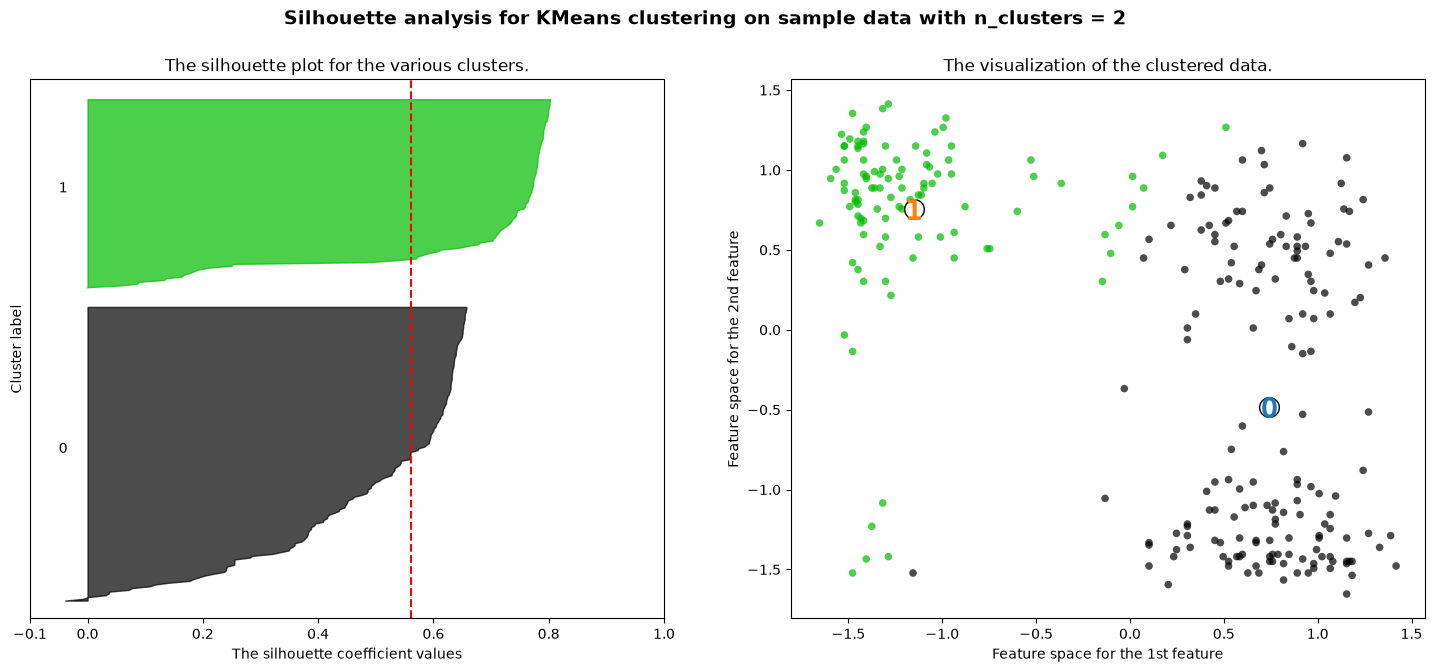

In [15]:
import matplotlib.cm as cm
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(18, 7)
# The 1st subplot is the silhouette plot
# The silhouette coefficient can range from -1, 1 but in this example all
# lie within [-0.1, 1]
ax1.set_xlim([-0.1, 1])
# The (n_clusters+1)*10 is for inserting blank space between silhouette
# plots of individual clusters, to demarcate them clearly.
ax1.set_ylim([0, len(data_faithful) + (ncluster + 1) * 10])

# Initialize the clusterer with n_clusters value and a random generator
# seed of 10 for reproducibility.
clusterer = KMeans(n_clusters=ncluster, random_state=10)
cluster_labels = clusterer.fit_predict(data_faithful)

# The silhouette_score gives the average value for all the samples.
# This gives a perspective into the density and separation of the formed
# clusters
silhouette_avg = silhouette_score(data_faithful, cluster_labels)
print(
    "For n_clusters =",
    ncluster,
    "The average silhouette_score is :",
    silhouette_avg,
)

# Compute the silhouette scores for each sample
sample_silhouette_values = silhouette_samples(data_faithful, cluster_labels)

y_lower = 10
for i in range(ncluster):
    # Aggregate the silhouette scores for samples belonging to
    # cluster i, and sort them
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / ncluster)
    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )

    # Label the silhouette plots with their cluster numbers at the middle
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the 0 samples

ax1.set_title("The silhouette plot for the various clusters.")
ax1.set_xlabel("The silhouette coefficient values")
ax1.set_ylabel("Cluster label")

# The vertical line for average silhouette score of all the values
ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

ax1.set_yticks([])  # Clear the yaxis labels / ticks
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

# 2nd Plot showing the actual clusters formed
colors = cm.nipy_spectral(cluster_labels.astype(float) / ncluster)
ax2.scatter(
    data_faithful[:, 0], data_faithful[:, 1], marker="o", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
)

# Labeling the clusters
centers = clusterer.cluster_centers_
# Draw white circles at cluster centers
ax2.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="o",
    c="white",
    alpha=1,
    s=200,
    edgecolor="k",
)

for i, c in enumerate(centers):
    ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=200, edgecolor=None)

ax2.set_title("The visualization of the clustered data.")
ax2.set_xlabel("Feature space for the 1st feature")
ax2.set_ylabel("Feature space for the 2nd feature")

plt.suptitle(
    "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
    % ncluster,
    fontsize=14,
    fontweight="bold",
)

### Choix du nombre de groupes : la méthode du coude

La méthode du coude vise à trouver le nombre optimal de groupes. Elle consiste à exécuter l'algorithme de partitionnement avec un nombre croissant de groupes $k$, en mesurant la distance moyenne entre les points de données et les centroïdes des groupes. Deux métriques sont typiques dans la méthode du coude :

* **Distorsion** : la moyenne des carrés des distances aux centres des groupes respectifs. La distance euclidienne est typiquement utilisée.
* **Inertie** : la somme des carrés des distances des échantillons à leur centre de groupe le plus proche.

Pour chaque valeur de $k$, nous calculons la moyenne du carré de la distance entre les points de données et le centroïde de leur groupe d'appartenance. Nous traçons ensuite cette valeur en fonction de $k$. Avec un peu de chance, elle décroît puis atteint un plateau. Le nombre optimal de groupes est la valeur à l'inflexion — le « coude » de la courbe.

Nous illustrons la méthode sur les données standardisées d'Old Faithful.

In [16]:
def compute_elbow(data, clusters, centers, k):
    """
    """
    E = 0
    for i in range(0, k):
        distance = compute_distance(data[clusters == i, :], centers[i, :].reshape(1, -1), 1)
        E = E + np.mean(np.square(distance))
    return E

Calculez la valeur de E pour k entre 1 et 8 et tracez-la. Cherchez la valeur de $k$ où la courbe s'infléchit.

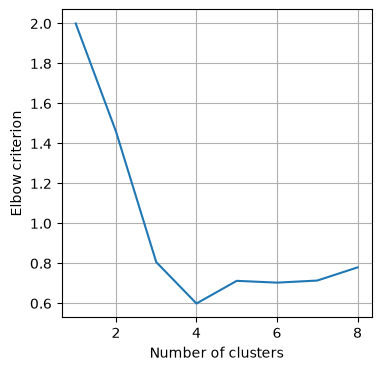

In [17]:
E = np.zeros(8)
for k in range(1, 9):
    (clusters, objective, centers) = my_kmeans(data_faithful, k)
    E[k - 1] = compute_elbow(data_faithful, clusters, centers, k)

plt.figure(figsize=(4, 4))
plt.plot(np.arange(1, 9), E)
plt.xlabel('Number of clusters')
plt.ylabel('Elbow criterion')
plt.grid(True)

La méthode du coude ne fonctionne pas toujours très bien. Par exemple, voyez ce qui arrive quand les points se rapprochent les uns des autres. Comme `data_faithful` est standardisé et centré en zéro, nous contractons les données vers l'origine.

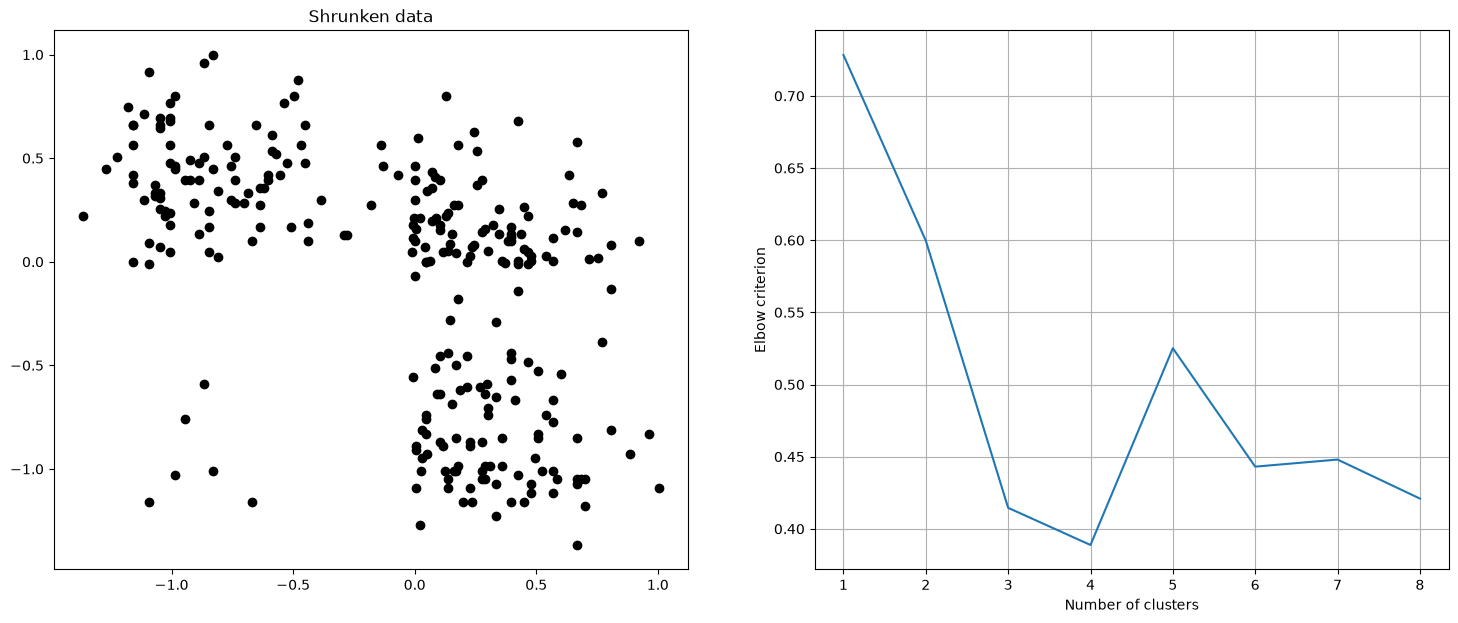

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(18, 7)
alpha = 0.5
origin = np.array([0.0, 0.0])
data_shrink = origin + alpha * np.sign(data_faithful - origin) * np.power(np.abs(data_faithful - origin), 2.0)
ax1.plot(data_shrink[:, 0], data_shrink[:, 1], 'ko')
ax1.set_title('Shrunken data')

E = np.zeros(8)
for k in range(1, 9):
    (clusters, objective, centers) = my_kmeans(data_shrink, k)
    E[k - 1] = compute_elbow(data_shrink, clusters, centers, k)
ax2.plot(np.arange(1, 9), E)
ax2.set_xlabel('Number of clusters')
ax2.set_ylabel('Elbow criterion')
ax2.grid(True)

Voyons ce qui se passe quand on diminue le nombre de données.

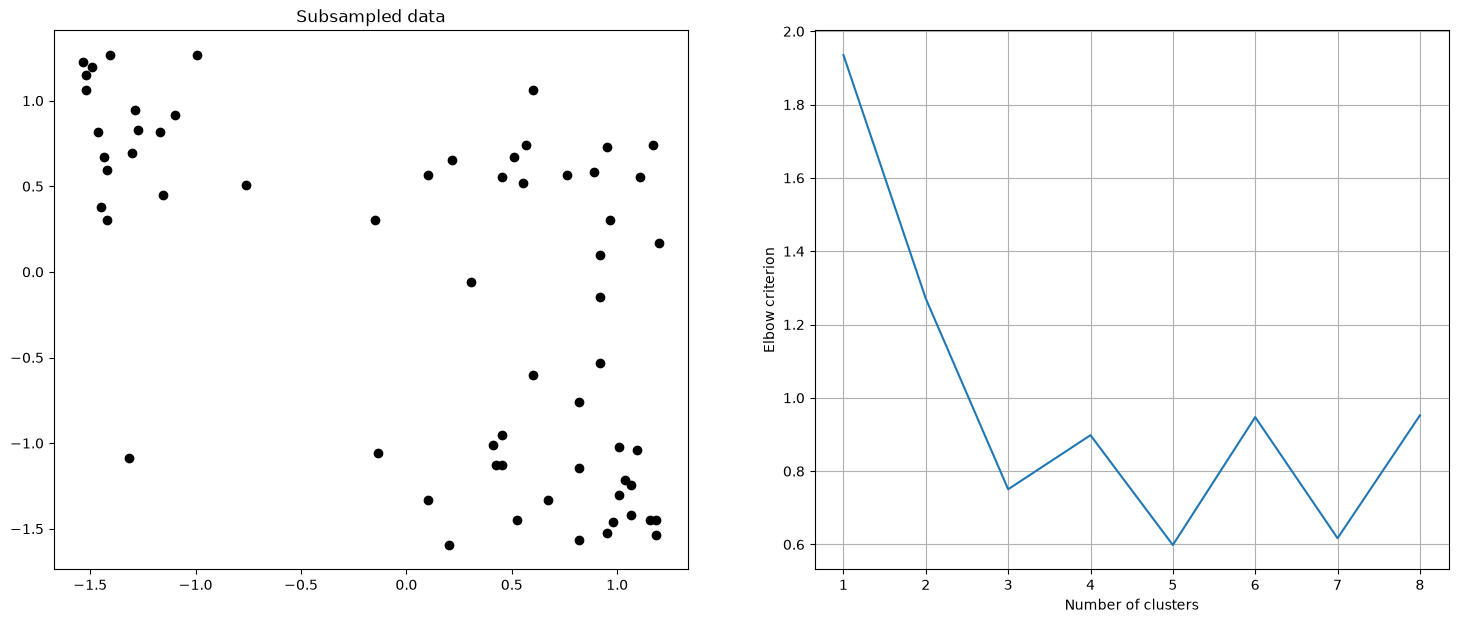

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(18, 7)
alpha = 0.2
indices = rng.uniform(size=np.shape(data_faithful)[0])
subdata = data_faithful[indices < alpha, :]
ax1.plot(subdata[:, 0], subdata[:, 1], 'ko')
ax1.set_title('Subsampled data')
E = np.zeros(8)
for k in range(1, 9):
    (clusters, objective, centers) = my_kmeans(subdata, k)
    E[k - 1] = compute_elbow(subdata, clusters, centers, k)
ax2.plot(np.arange(1, 9), E)
ax2.set_xlabel('Number of clusters')
ax2.set_ylabel('Elbow criterion')
ax2.grid(True)

Ces deux tests de robustesse montrent les limites du critère du coude : quand les groupes se rapprochent, ou quand les données se raréfient, la courbe perd son inflexion nette et le choix de $k$ devient ambigu. Utilisez la méthode du coude comme un guide, pas comme une règle, et recoupez avec le score de silhouette.

### Répéter k-means
Le résultat est très sensible à la position des centroïdes initiaux. Répétez le partitionnement N fois et choisissez celui qui a la meilleure fonction objectif.

In [20]:
def repeat_kmeans(data, k, N):
    """
    """
    # Initialization
    objective = np.zeros(N)
    clusters = np.zeros((N, np.shape(data)[0]))
    centers = np.zeros((N, k, np.shape(data)[1]))
    # Run K-means N times
    for i in range(0, N):
        result = my_kmeans(data, k)
        clusters[i, :] = result[0]
        objective[i] = result[1]
        centers[i, :, :] = result[2]
    # Choose the clustering with the best value of the objective function
    best = np.argmin(objective)
    return (clusters[best, :], objective[best], centers[best, :, :])

Répétons k-means 20 fois avec k = 2 et gardons la meilleure exécution.

Text(0.5, 1.0, 'Best of 20 k-means runs')

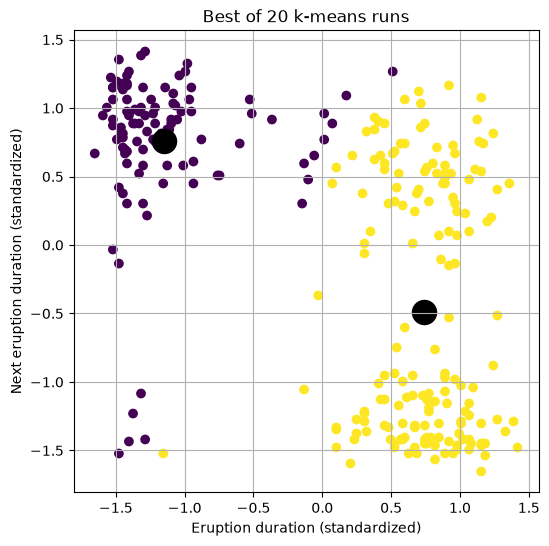

In [21]:
N = 20
k = 2
(clusters, objective, centers) = repeat_kmeans(data_faithful, k, N)

plt.figure(figsize=(6, 6))
plt.scatter(data_faithful[:, 0], data_faithful[:, 1], c=clusters)
plt.scatter(centers[:, 0], centers[:, 1], marker='o', s=300, c='black')
plt.xlabel('Eruption duration (standardized)')
plt.ylabel('Next eruption duration (standardized)')
plt.grid(True)
plt.title('Best of {:d} k-means runs'.format(N))

K-means peut être lent à calculer et il existe des pistes pour l'accélérer. Une solution est le [K-means par **mini-lots** (*mini-batch*)](https://scikit-learn.org/stable/modules/clustering.html#mini-batch-k-means), qui prend un sous-ensemble des données à chaque itération pour construire les centroïdes.

## 4. Partitionnement hiérarchique

Avec k-means, nous utilisons la distance euclidienne et prescrivons le nombre de groupes K.

En partitionnement hiérarchique, nous choisissons différentes métriques de distance, visualisons la structure des données, puis décidons du nombre de groupes. Deux approches construisent la hiérarchie de groupes :

* **Agglomérative** : chaque point démarre dans son propre groupe. Les données sont fusionnées par paires, ce qui crée une hiérarchie de groupes.
* **Divisive** : au départ, toutes les données forment un seul groupe. Les données sont récursivement scindées en groupes de plus en plus petits.

Il existe plusieurs types de *liaisons* (*linkages*). sklearn propose une [documentation](https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering) détaillée, surtout pour l'agglomératif. Les différentes méthodes de liaison sont :

* **Ward** minimise la somme des carrés des écarts au sein de tous les groupes. C'est une approche de minimisation de la variance, en ce sens proche de la fonction objectif de k-means, mais traitée par une approche hiérarchique agglomérative.
* La liaison **maximum**, ou complète, minimise la distance maximale entre les observations de paires de groupes.
* La liaison **moyenne** minimise la moyenne des distances entre toutes les observations de paires de groupes.
* La liaison **simple** minimise la distance entre les observations les plus proches de paires de groupes.

Importons d'abord les paquets pertinents.

In [22]:
from matplotlib import rcParams
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist

rcParams.update({'font.size': 18})
plt.rcParams['figure.figsize'] = [12, 12]

Ici, nous créons un jeu de données factice à 2 groupes qui s'entremêlent en quelques points.

In [23]:
# Training and testing set sizes
n = 100 # Train

# Random ellipse 1 centered at (0,0)
x = rng.standard_normal(n)
y = 0.5*rng.standard_normal(n)

# Random ellipse 2 centered at (1,-2)
x2 = rng.standard_normal(n) + 1
y2 = 0.2*rng.standard_normal(n) - 2

# Rotate ellipse 2 by theta
theta = np.pi/4
A = np.zeros((2,2))
A[0,0] = np.cos(theta)
A[0,1] = -np.sin(theta)
A[1,0] = np.sin(theta)
A[1,1] = np.cos(theta)

x3 = A[0,0]*x2 + A[0,1]*y2
y3 = A[1,0]*x2 + A[1,1]*y2

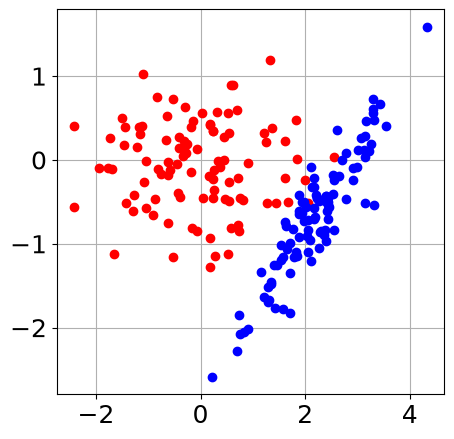

In [24]:
plt.figure(1,figsize=(5,5))
plt.plot(x[:],y[:],'ro')
plt.plot(x3[:],y3[:],'bo')
plt.grid(True)
plt.show()

Combinons ces deux jeux de données en un seul.

In [25]:
X1 = np.column_stack((x3[:],y3[:]))
X2 = np.column_stack((x[:],y[:]))
X = np.concatenate((X1,X2))

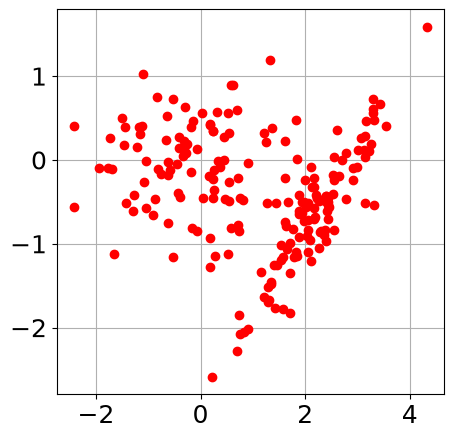

In [26]:
plt.figure(1,figsize=(5,5))
plt.plot(X[:,0],X[:,1],'ro')
plt.grid(True)
plt.show()

Explorons d'abord les dendrogrammes.

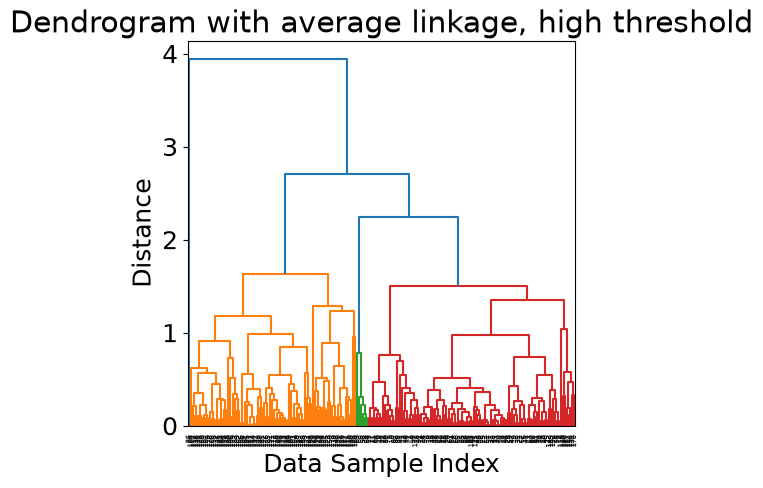

In [27]:
## Dendrograms
Y = pdist(X,metric='euclidean')
Z = hierarchy.linkage(Y,method='average')
thresh = 0.5*np.max(Z[:,2])

plt.figure(1,figsize=(5,5))
dn = hierarchy.dendrogram(Z,p=100,color_threshold=thresh)
plt.xlabel('Data Sample Index')
plt.ylabel('Distance')
plt.title('Dendrogram with average linkage, high threshold')
plt.show()

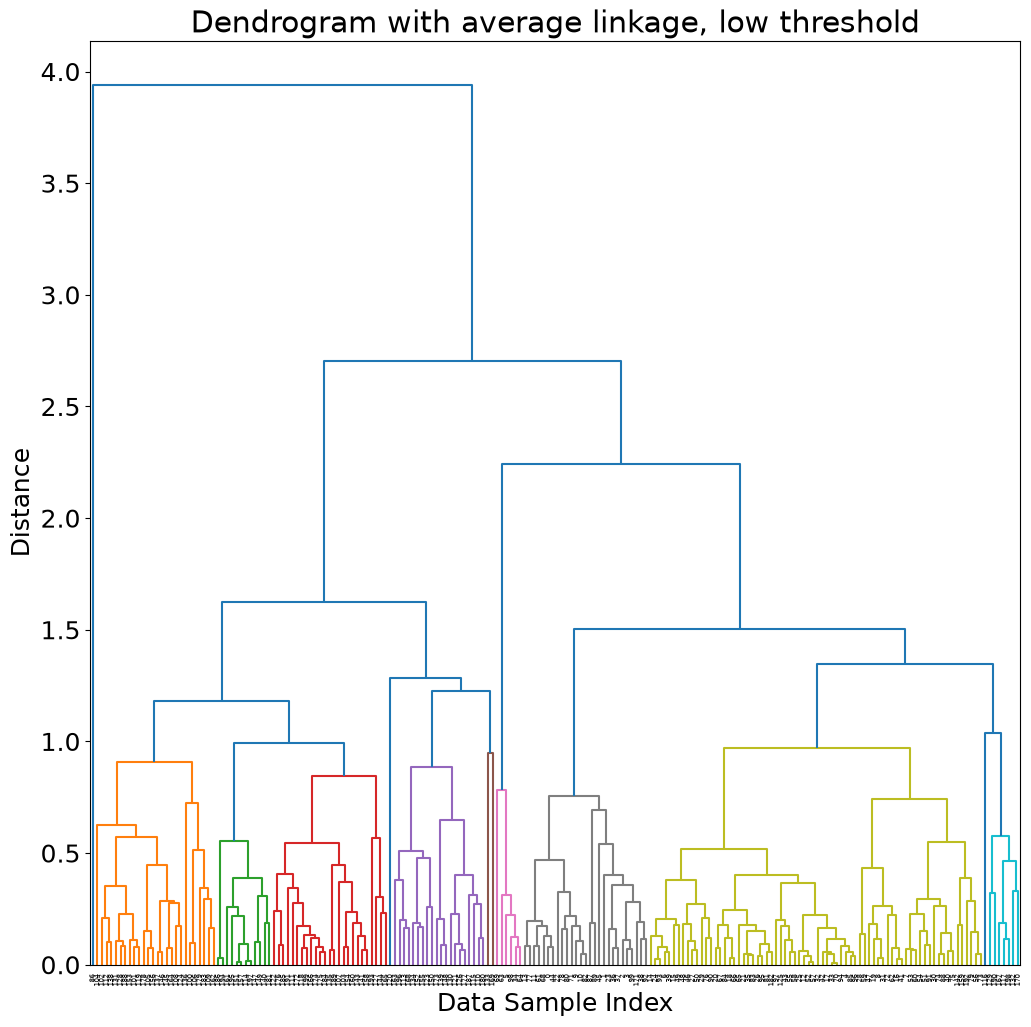

In [28]:
thresh = 0.25*np.max(Z[:,2])
plt.figure()
dn = hierarchy.dendrogram(Z,p=100,color_threshold=thresh)
plt.xlabel('Data Sample Index')
plt.ylabel('Distance')
plt.title('Dendrogram with average linkage, low threshold')
plt.show()

Nous avons maintenant exploré la structure des données et bâti une intuition sur le nombre de groupes et la répartition des échantillons dans les groupes.

Ensuite, nous choisissons un seuil de distance et assignons à chaque point de données un identifiant de groupe.

Dans scikit-learn, l'algorithme entier est incorporé dans la fonction ```AgglomerativeClustering``` [doc sklearn ici](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html). La fonction requiert tout de même soit un seuil de distance, soit un nombre de groupes pour effectuer le partitionnement et assigner un identifiant de groupe à chaque échantillon.

In [29]:
from sklearn.cluster import AgglomerativeClustering
# Let's first find a reasonable distance threshold by precalculating the linkage matrix
Z = hierarchy.linkage(X, "average")
thresh = 0.85*np.max(Z[:,2])    # choose a threshold distance
print(thresh)
# design model
model = AgglomerativeClustering(distance_threshold=thresh,linkage="average", n_clusters=None)
# fit model and predict clusters on the data samples
clusterID = model.fit_predict(X)

3.349805679694126


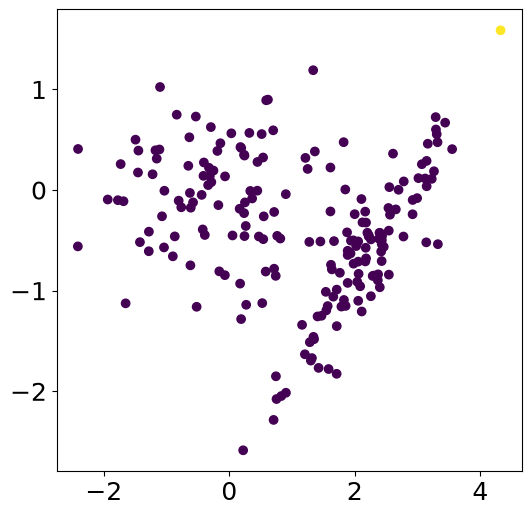

In [30]:
plt.figure(figsize=(6,6))
plt.scatter(X[:,0],X[:,1],c=clusterID)

## 5. PCA avant partitionnement

Générons des données synthétiques.

(-6.0, 3.0)

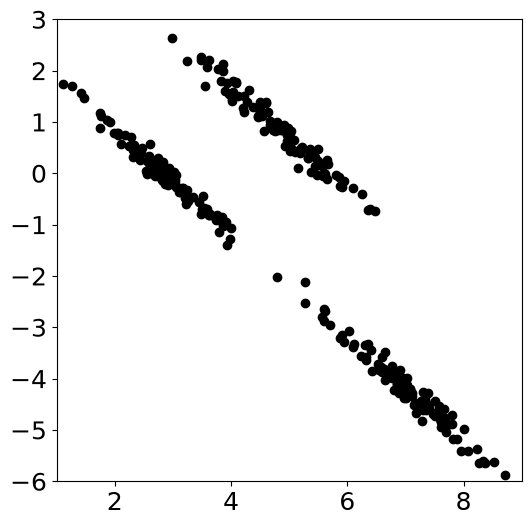

In [31]:
centers = np.array([[2, 2], [2, 8], [4, 3]])
radius = [0.1, 1]
synthetics = np.empty([0, 2])
for i in range(0, 3):
    X = centers[i, 0] + radius[0] * rng.standard_normal(100)
    Y = centers[i, 1] + radius[1] * rng.standard_normal(100)
    U = (X + Y) * np.sqrt(2) / 2
    V = (X - Y) * np.sqrt(2) / 2
    synthetics = np.concatenate([synthetics, np.vstack((U, V)).T])
plt.figure(figsize=(6,6))
plt.plot(synthetics[:,0], synthetics[:,1], 'ko')
plt.xlim(1, 9)
plt.ylim(-6, 3)

Faisons maintenant un partitionnement k-means à 3 groupes.

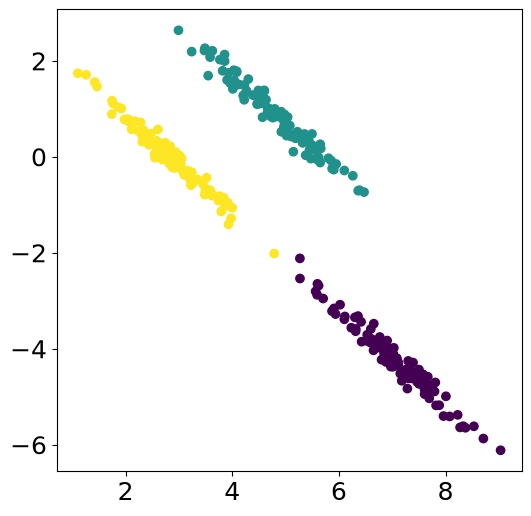

In [32]:
(clusters, objective, centers) = my_kmeans(synthetics, 3)
plt.figure(figsize=(6,6))
plt.scatter(synthetics[:,0], synthetics[:,1], c=clusters)

Que se passe-t-il si nous appliquons PCA + normalisation avant le partitionnement ?

In [33]:
pca = PCA(n_components=2)
synthetics_pca = pca.fit_transform(synthetics)

In [34]:
scaler = preprocessing.StandardScaler().fit(synthetics_pca)
synthetics_scaled = scaler.transform(synthetics_pca)

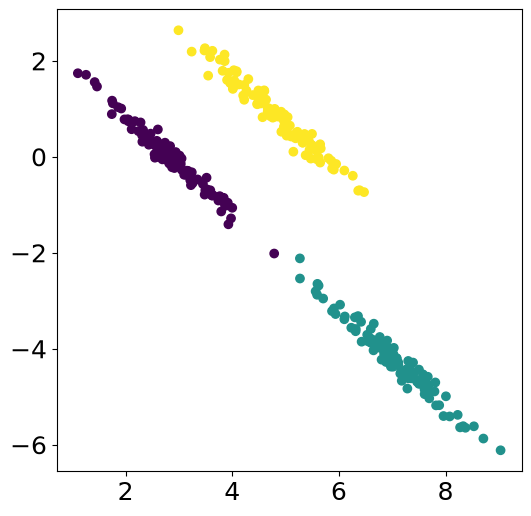

In [35]:
(clusters, objective, centers) = my_kmeans(synthetics_scaled, 3)
plt.figure(figsize=(6,6))
plt.scatter(synthetics[:,0], synthetics[:,1], c=clusters)

## Exercice : partitionner des sources sismiques volcaniques et tectoniques

Les volcans comme le mont Hood, volcan englacé de la chaîne des Cascades, produisent un mélange de sources sismiques : séismes volcaniques et tectoniques, événements de surface comme les chutes de blocs et les avalanches, et bruit de fond — les observatoires français trient les mêmes familles d'événements au piton de la Fournaise ou à la Soufrière de Guadeloupe. Les analystes étiquettent ces événements à la main. Le partitionnement peut-il retrouver les types de sources à partir des seules caractéristiques des formes d'onde ?

Nous utilisons un jeu de données organisé d'événements sismiques du Nord-Ouest Pacifique — séisme, explosion, événement de surface et bruit, 1000 de chaque — décrits par des caractéristiques physiques des formes d'onde (forme spectrale, statistiques d'enveloppe, kurtosis, énergies par bande de fréquence). Le jeu de données est archivé sur Zenodo : [DOI 10.5281/zenodo.14025693](https://doi.org/10.5281/zenodo.14025693). Il revient au carnet 3.5 pour la classification supervisée.

**Étape 1 : charger les données.** Le chargeur ci-dessous télécharge et met en cache les quatre fichiers de classes, les concatène, et supprime la seule colonne de caractéristique à valeurs manquantes.

In [36]:
import pooch

SEISMIC_FILES = {
    "1000_earthquakes_physical_features.csv": "md5:28129c8dd1b3e14f655d489577b841b5",
    "1000_explosion_physical_features.csv": "md5:af1342d32e163e961e043364136359b0",
    "1000_noise_physical_features.csv": "md5:16cdb992fed6cf6273d5624f5df905da",
    "1000_surface_physical_features.csv": "md5:9a2c2643030cf058704d68e130654e9d",
}

frames = []
for fname, checksum in SEISMIC_FILES.items():
    path = pooch.retrieve(
        url=f"https://zenodo.org/api/records/14025693/files/{fname}/content",
        known_hash=checksum,
        fname=fname,
        path=pooch.os_cache("mlgeo"),
    )
    frames.append(pd.read_csv(path, index_col=0))
seismic = pd.concat(frames, ignore_index=True)
seismic = seismic.dropna(axis=1)  # drops the one feature column with missing values

In [37]:
X_seis = seismic.drop(columns=["source", "serial_no"])
y_seis = seismic["source"]
print(X_seis.shape)
y_seis.value_counts()

(4000, 61)


source
earthquake       1000
explosion        1000
noise            1000
surface event    1000
Name: count, dtype: int64

**Étape 2 : standardiser les 61 caractéristiques.** Les caractéristiques couvrent plusieurs ordres de grandeur : la mise à l'échelle est obligatoire avant toute méthode fondée sur la distance.

In [38]:
scaler = preprocessing.StandardScaler()
X_seis_scaled = scaler.fit_transform(X_seis)

**Étape 3 : PCA.** Tracez la variance expliquée cumulée et gardez assez de composantes principales pour expliquer environ 80 % de la variance.

15 components explain 80% of the variance


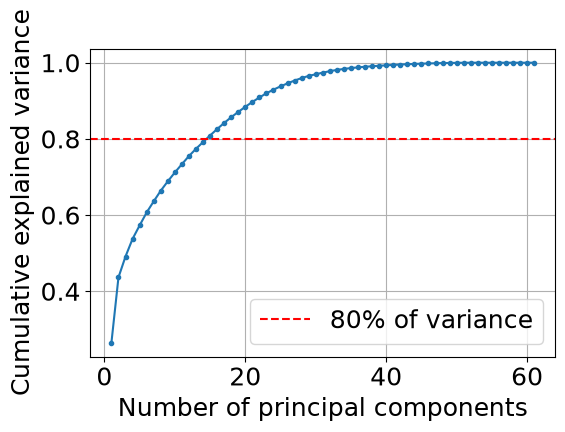

In [39]:
pca = PCA().fit(X_seis_scaled)
cumvar = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(cumvar) + 1), cumvar, marker='.')
plt.axhline(0.80, color='red', linestyle='--', label='80% of variance')
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative explained variance')
plt.legend()
plt.grid(True)

n_pcs = int(np.searchsorted(cumvar, 0.80) + 1)
print(f"{n_pcs} components explain 80% of the variance")
X_seis_pca = pca.transform(X_seis_scaled)[:, :n_pcs]

**Étape 4 : k-means à 4 groupes** sur les composantes principales. Nous savons qu'il y a quatre types de sources, donc nous posons k = 4.

In [40]:
kmeans_seis = KMeans(n_clusters=4, random_state=42).fit(X_seis_pca)
cluster_labels = kmeans_seis.labels_

**Étape 5 : comparer les groupes aux étiquettes vraies.** Ce jeu de données a des étiquettes de vérité terrain, donc nous pouvons noter le partitionnement avec trois métriques :

* L'**homogénéité** vaut 1 quand chaque groupe ne contient que des membres d'une seule classe.
* La **complétude** vaut 1 quand tous les membres d'une classe tombent dans le même groupe.
* La **V-mesure** est la moyenne harmonique des deux. Les trois vont de 0 (assignation aléatoire) à 1 (accord parfait).

In [41]:
h, c, v = metrics.homogeneity_completeness_v_measure(y_seis, cluster_labels)
print(f"Homogeneity:  {h:.3f}")
print(f"Completeness: {c:.3f}")
print(f"V-measure:    {v:.3f}")

Homogeneity:  0.363
Completeness: 0.393
V-measure:    0.377


**Étape 6 : croiser les groupes et les types de sources dans un tableau.**

In [42]:
ct = pd.crosstab(cluster_labels, y_seis, rownames=['cluster'], colnames=['source'])
ct

source,earthquake,explosion,noise,surface event
cluster,,,,
0,141,732,14,794
1,71,52,698,125
2,764,117,41,48
3,24,99,247,33


Text(0.5, 1.0, 'K-means clusters vs. true source types')

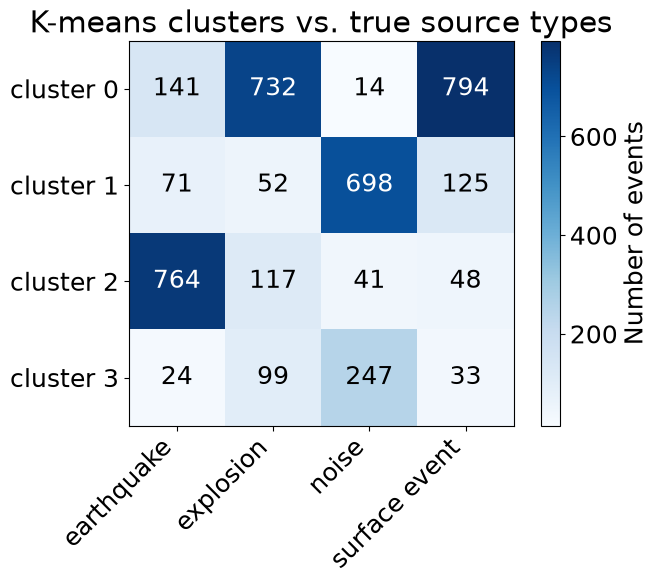

In [43]:
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(ct.values, cmap='Blues')
ax.set_xticks(range(len(ct.columns)))
ax.set_xticklabels(ct.columns, rotation=45, ha='right')
ax.set_yticks(range(len(ct.index)))
ax.set_yticklabels([f'cluster {i}' for i in ct.index])
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j, i, ct.values[i, j], ha='center', va='center',
                color='white' if ct.values[i, j] > ct.values.max()/2 else 'black')
fig.colorbar(im, ax=ax, label='Number of events')
ax.set_title('K-means clusters vs. true source types')

Sans jamais voir une étiquette, k-means retrouve une bonne partie de la structure : un groupe est dominé par les séismes, un autre par le bruit. Regardez dans votre tableau croisé la paire de sources qui se mélange le plus — ici, les explosions et les événements de surface partagent largement un même groupe. C'est physiquement plausible : les deux sont des sources superficielles, proches de la surface (tirs de carrière, chutes de blocs, avalanches), donc leurs formes d'onde portent peu de l'énergie haute fréquence profonde qui distingue les séismes, et leurs caractéristiques d'enveloppe et spectrales se recouvrent. Les classifieurs supervisés du carnet 3.5 font bien mieux sur les mêmes caractéristiques — c'est tout l'intérêt des étiquettes.

```{admonition} À vous de jouer
:class: tip
* Faites varier k de 2 à 8 et suivez le score de silhouette et l'inertie (méthode du coude). k = 4 se détache-t-il ?
* Essayez le partitionnement sur les caractéristiques mises à l'échelle, sans PCA. La V-mesure change-t-elle ?
* Essayez `AgglomerativeClustering` avec 4 groupes et comparez sa V-mesure à celle de k-means.
```